# Libraries

In [195]:
import numpy as np
import scipy
from scipy import signal
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math

root = str(Path().resolve().parent)
if root not in sys.path:
    sys.path.append(root)
print(*sys.path, sep="\n")

%matplotlib ipympl
# %matplotlib inline

/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/home/ryanwtsai/repos/digital-communication-simulator/venv/lib/python3.12/site-packages
/home/ryanwtsai/repos/digital-communication-simulator


In [158]:
from importlib import reload
from digcommpy import calc, ofdm, rf_analog, rf_tx_fw, tonegen, digital_filter_design, digital_hw_algo as dighw, rf_estimation as rf_est, beamforming

reload(calc)
reload(ofdm)
reload(rf_analog)
reload(rf_tx_fw)
reload(tonegen)
reload(digital_filter_design)
reload(dighw)
reload(rf_est)
reload(beamforming)

<module 'digcommpy.beamforming' from '/home/ryanwtsai/repos/digital-communication-simulator/digcommpy/beamforming.py'>

# Conventional beamforming

0.2501385702439108
1.0


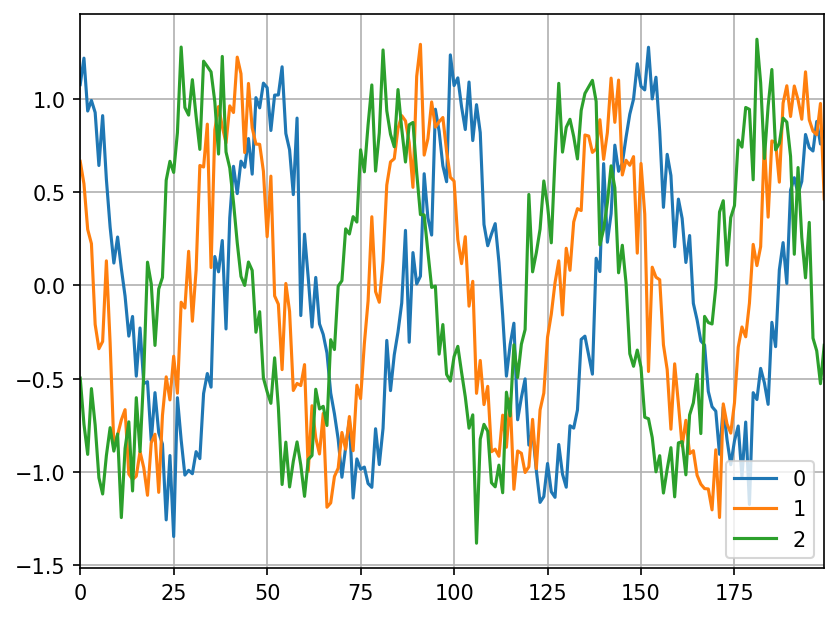

In [185]:
add_noise = True
Nr = 3
theta = 20*np.pi/180
# theta = 0

ula = beamforming.ULA(Nr, theta)
ula.fit()

N = 10000
ftone = 0.02e6
fs = 1e6
x = np.exp(1j*2*np.pi*ftone/fs*np.arange(N, dtype="float"))

power = 10*np.log10(0.25**2/50/1e-3)
# power = 10*np.log10(0.5**2/50/1e-3)
awgn = rf_analog.AWGN(power, fs, fs)
n = awgn.transform(np.zeros(N, dtype="float"))
print(calc.rms(n))
print(calc.rms(x))

ula_bf = beamforming.ULABeamform(Nr, theta)
ula_bf.fit()

X = ula.transform(x)
if add_noise:
    X = awgn.transform(X)
y = ula_bf.transform(X)

fig, ax = plt.subplots(dpi=150)

ax.plot(X[0, :200].squeeze().real, label="0")
ax.plot(X[1, :200].squeeze().real, label="1")
ax.plot(X[2, :200].squeeze().real, label="2")
# ax.plot(y[:200].real, label="Beamformed")
ax.set_xlim(left=0, right=200-1)
ax.grid()
ax.legend()

# DOA with conventional beamforming

19.99999999999998


Text(0.5, 1.0, 'DOA Sweep, theta=20, n_rms=0.5, N=10000')

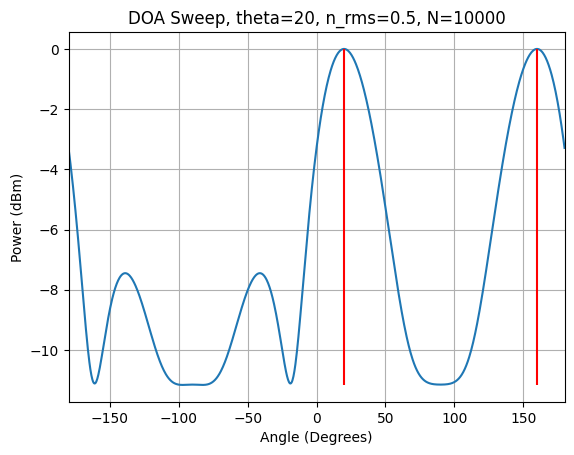

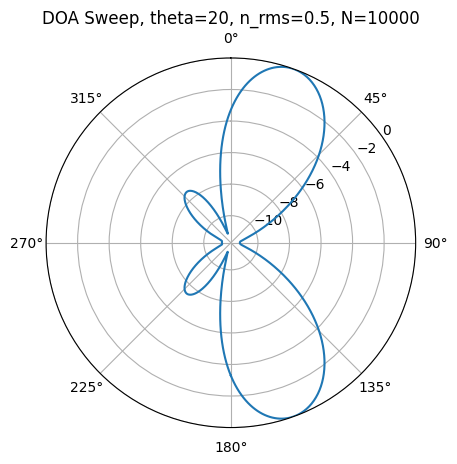

In [191]:
Nr = 3
theta = 20*np.pi/180
rms = 0.5
N = 10000
# N = 100000

# Nr = 3*2
# rms = 0
# N = 100000




ula = beamforming.ULA(Nr, theta)
ula_bf = beamforming.ULABeamform(Nr, theta)


ftone = 0.02e6
fs = 1e6
x = np.exp(1j*2*np.pi*ftone/fs*np.arange(N, dtype="float"))

# power = 10*np.log10(0.25**2/50/1e-3)
if rms == 0:
    awgn = None
else:
    power = 10*np.log10(rms**2/50/1e-3)
    awgn = rf_analog.AWGN(power, fs, fs)

thetas, powers = beamforming.ula_doa(x, ula, ula_bf, awgn)

print(thetas[np.argmax(powers)]*180/np.pi)

title = f"DOA Sweep, theta={round(theta*180/np.pi)}, n_rms={rms}, N={N}"

fig, ax = plt.subplots(dpi=100)
ax.plot(thetas*180/np.pi, powers)
ax.vlines([round(theta*180/np.pi), round((np.pi-theta)*180/np.pi)], ymin=powers.min(), ymax=powers.max(), colors="r")
ax.set_xlim(left=-180, right=180)
ax.set_ylabel("Power (dBm)")
ax.set_xlabel("Angle (Degrees)")
ax.set_title(title)
ax.grid()

fig, ax = plt.subplots(dpi=100, subplot_kw={'projection': 'polar'})
ax.plot(thetas, powers) # MAKE SURE TO USE RADIAN FOR POLAR
ax.set_theta_zero_location('N') # make 0 degrees point up
ax.set_theta_direction(-1) # increase clockwise
ax.set_rlabel_position(55)  # Move grid labels away from other labels
ax.set_title(title)
# plt.show()

## Sweep noise power

19.99999999999998
19.99999999999998
19.99999999999998


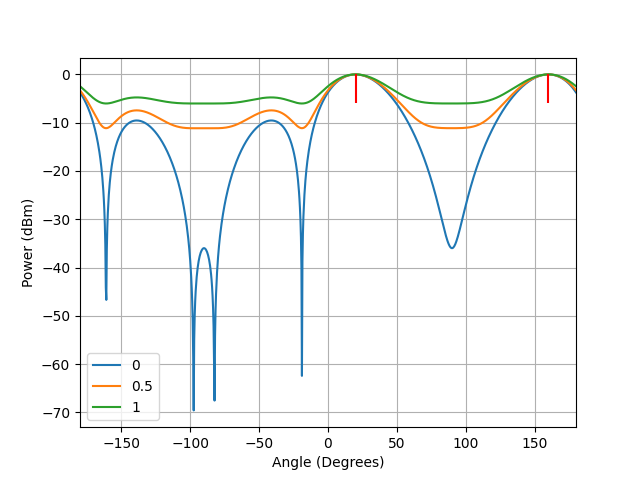

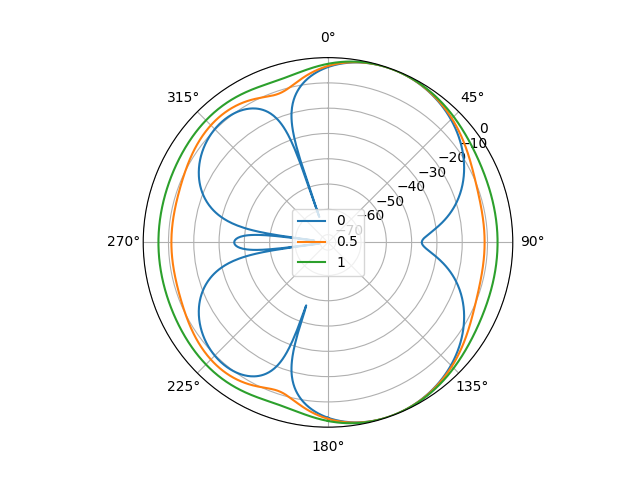

In [ ]:
Nr = 3
theta = 20*np.pi/180
rms_list = [0, 0.5, 1]
N = 10000
# N = 100000

# Nr = 3*2
# rms = 0
# N = 100000




ula = beamforming.ULA(Nr, theta)
ula_bf = beamforming.ULABeamform(Nr, theta)


ftone = 0.02e6
fs = 1e6
x = np.exp(1j*2*np.pi*ftone/fs*np.arange(N, dtype="float"))

title = f"DOA Sweep, theta={round(theta*180/np.pi)}, n_rms={rms}, N={N}"
fig1, ax1 = plt.subplots(dpi=100)
fig2, ax2 = plt.subplots(dpi=100, subplot_kw={'projection': 'polar'})
for rms in rms_list:
    if rms == 0:
        awgn = None
    else:
        power = 10*np.log10(rms**2/50/1e-3)
        awgn = rf_analog.AWGN(power, fs, fs)

    thetas, powers = beamforming.ula_doa(x, ula, ula_bf, awgn)

    print(thetas[np.argmax(powers)]*180/np.pi)

    

    
    ax1.plot(thetas*180/np.pi, powers, label=rms)
    

    
    ax2.plot(thetas, powers, label=rms) # MAKE SURE TO USE RADIAN FOR POLAR
    
    # plt.show()

ax1.vlines([round(theta*180/np.pi), round((np.pi-theta)*180/np.pi)], ymin=powers.min(), ymax=powers.max(), colors="r")
ax1.set_xlim(left=-180, right=180)
ax1.set_ylabel("Power (dBm)")
ax1.set_xlabel("Angle (Degrees)")
# ax1.set_title(title)
ax1.legend()
ax1.grid()

ax2.set_theta_zero_location('N') # make 0 degrees point up
ax2.set_theta_direction(-1) # increase clockwise
ax2.set_rlabel_position(55)  # Move grid labels away from other labels
# ax2.set_title(title)
ax2.legend()

## Sweep Nr

19.99999999999998
19.99999999999998
19.99999999999998


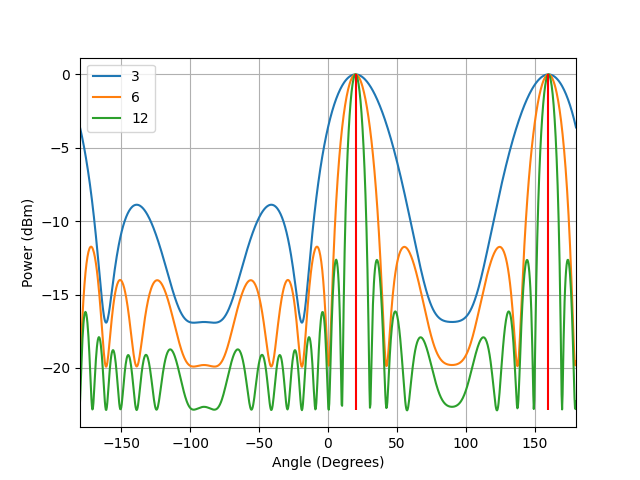

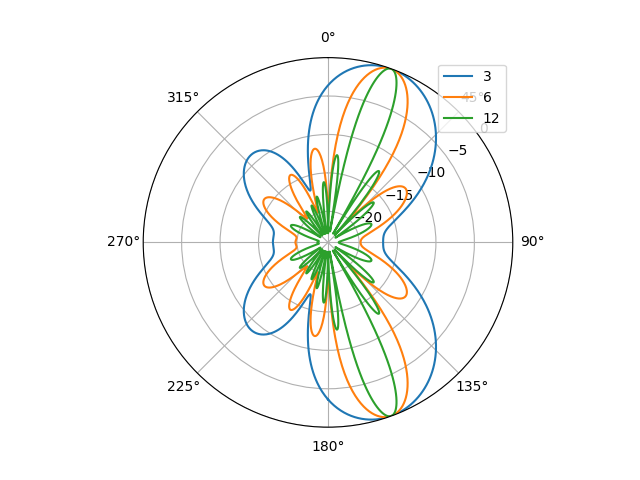

In [200]:
Nr_list = [3, 6, 12]
theta = 20*np.pi/180
rms = 0.25
N = 10000
# N = 100000

# Nr = 3*2
# rms = 0
# N = 100000







ftone = 0.02e6
fs = 1e6
x = np.exp(1j*2*np.pi*ftone/fs*np.arange(N, dtype="float"))

title = f"DOA Sweep, theta={round(theta*180/np.pi)}, n_rms={rms}, N={N}"
fig1, ax1 = plt.subplots(dpi=100)
fig2, ax2 = plt.subplots(dpi=100, subplot_kw={'projection': 'polar'})
for Nr in Nr_list:
    ula = beamforming.ULA(Nr, theta)
    ula_bf = beamforming.ULABeamform(Nr, theta)

    if rms == 0:
        awgn = None
    else:
        power = 10*np.log10(rms**2/50/1e-3)
        awgn = rf_analog.AWGN(power, fs, fs)

    thetas, powers = beamforming.ula_doa(x, ula, ula_bf, awgn)

    print(thetas[np.argmax(powers)]*180/np.pi)

    

    
    ax1.plot(thetas*180/np.pi, powers, label=Nr)
    

    
    ax2.plot(thetas, powers, label=Nr) # MAKE SURE TO USE RADIAN FOR POLAR
    
    # plt.show()

ax1.vlines([round(theta*180/np.pi), round((np.pi-theta)*180/np.pi)], ymin=powers.min(), ymax=powers.max(), colors="r")
ax1.set_xlim(left=-180, right=180)
ax1.set_ylabel("Power (dBm)")
ax1.set_xlabel("Angle (Degrees)")
# ax1.set_title(title)
ax1.legend()
ax1.grid()

ax2.set_theta_zero_location('N') # make 0 degrees point up
ax2.set_theta_direction(-1) # increase clockwise
ax2.set_rlabel_position(55)  # Move grid labels away from other labels
# ax2.set_title(title)
ax2.legend()

[ 1.        +0.j          0.47618256+0.87934645j -0.54650034+0.83745888j]
(3, 1)
(1, 10000)
(3, 10000)


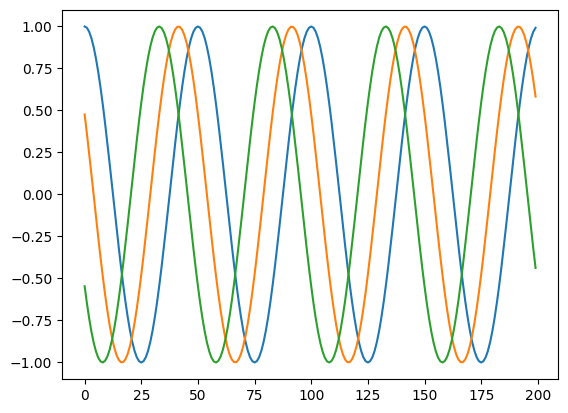

In [125]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate = 1e6
N = 10000 # number of samples to simulate

# Create a tone to act as the transmitter signal
t = np.arange(N)/sample_rate # time vector
f_tone = 0.02e6
tx = np.exp(2j * np.pi * f_tone * t)

d = 0.5 # half wavelength spacing
Nr = 3
theta_degrees = 20 # direction of arrival (feel free to change this, it's arbitrary)
theta = theta_degrees / 180 * np.pi # convert to radians
s = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta)) # Steering Vector
print(s) # note that it's 3 elements long, it's complex, and the first element is 1+0j

s = s.reshape(-1,1) # make s a column vector
print(s.shape) # 3x1
tx = tx.reshape(1,-1) # make tx a row vector
print(tx.shape) # 1x10000

X = s @ tx # Simulate the received signal X through a matrix multiply
print(X.shape) # 3x10000.  X is now going to be a 2D array, 1D is time and 1D is the spatial dimension

n = np.random.randn(Nr, N) + 1j*np.random.randn(Nr, N)
# X = X + 0.5*n # X and n are both 3x10000

plt.plot(np.asarray(X[0,:]).squeeze().real[0:200]) # the asarray and squeeze are just annoyances we have to do because we came from a matrix
plt.plot(np.asarray(X[1,:]).squeeze().real[0:200])
plt.plot(np.asarray(X[2,:]).squeeze().real[0:200])
plt.show()

19.99999999999998


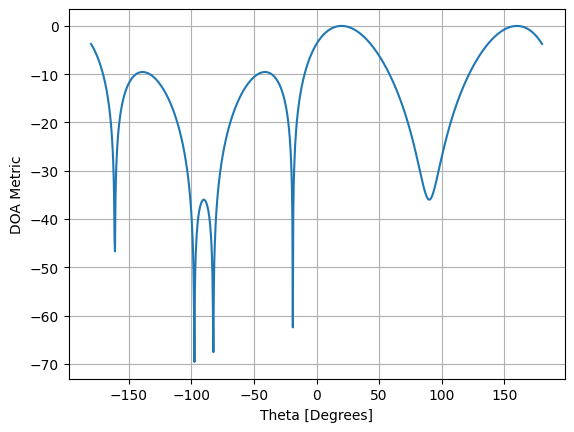

In [126]:
theta_scan = np.linspace(-1*np.pi, np.pi, 1000) # 1000 different thetas between -180 and +180 degrees
results = []
for theta_i in theta_scan:
   w = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta_i)) # Conventional, aka delay-and-sum, beamformer
   X_weighted = w.conj().T @ X # apply our weights. remember X is 3x10000
   results.append(10*np.log10(np.var(X_weighted))) # power in signal, in dB so its easier to see small and large lobes at the same time
results -= np.max(results) # normalize (optional)

# print angle that gave us the max value
print(theta_scan[np.argmax(results)] * 180 / np.pi) # 19.99999999999998

plt.plot(theta_scan*180/np.pi, results) # lets plot angle in degrees
plt.xlabel("Theta [Degrees]")
plt.ylabel("DOA Metric")
plt.grid()
plt.show()

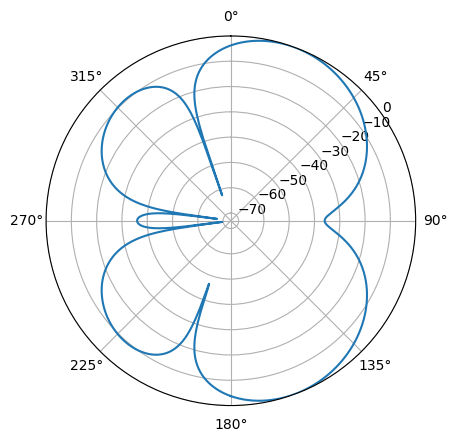

In [127]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(theta_scan, results) # MAKE SURE TO USE RADIAN FOR POLAR
ax.set_theta_zero_location('N') # make 0 degrees point up
ax.set_theta_direction(-1) # increase clockwise
ax.set_rlabel_position(55)  # Move grid labels away from other labels
plt.show()